# SpAM Analysis (Participant-wise, Domain-wise)

This notebook analyzes **Spatial Arrangement Method (SpAM)** data from the merged dataset.

- Coordinates are treated as **participant-relative**.
- Core unit of analysis is **(subject_id, domain)**.
- Distances, neighbourhood, and clustering are computed **within each participant-domain space**.

## 1) Setup and Configuration

In [1]:
import os
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

DATA_PATH = "merged_vft_spam_responses.csv"
OUT_DIR = "outputs_spam_hinglish"
os.makedirs(OUT_DIR, exist_ok=True)

print("Data path:", DATA_PATH)
print("Output dir:", OUT_DIR)

Data path: merged_vft_spam_responses.csv
Output dir: outputs_spam_hinglish


## 2) Read Merged Dataset and Validate Schema

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

display(df.head(3))

null_summary = df.isna().sum().sort_values(ascending=False)
print("\nTop null counts:")
display(null_summary.head(10))

dup_count = df.duplicated().sum()
print("Duplicate rows:", int(dup_count))

expected_cols = {"subject_id", "session_id", "domain", "position", "word", "language_type", "x", "y"}
missing_cols = expected_cols - set(df.columns)
print("Missing expected columns:", missing_cols if missing_cols else "None")

Shape: (1040, 9)
Columns: ['subject_id', 'session_id', 'domain', 'position', 'word', 'language_type', 'rt_ms', 'x', 'y']


,subject_id,session_id,domain,position,word,language_type,rt_ms,x,y
0,10255,1qmxoH7jT7VECeLUVEKU,colours,1,red,English,2558.3,0.076446,1.003870
1,10255,1qmxoH7jT7VECeLUVEKU,colours,2,blue,English,1464.6,0.080923,0.540248
2,10255,1qmxoH7jT7VECeLUVEKU,colours,3,green,English,1505.6,0.074953,0.097112



Top null counts:


subject_id       0
session_id       0
domain           0
position         0
word             0
language_type    0
rt_ms            0
x                0
y                0
dtype: int64

Duplicate rows: 0
Missing expected columns: None


## 3) Standardize Language Tags and Build Splits

In [3]:
def normalize_language(value):
    s = str(value).strip().lower()
    if "hinglish" in s:
        return "Hinglish"
    if s == "hindi" or "hindi" in s:
        return "Hindi"
    if "english" in s:
        return "English"
    return "Other"

spam_df = df.copy()
spam_df["language_group"] = spam_df["language_type"].apply(normalize_language)

hh_df = spam_df[spam_df["language_group"].isin(["Hindi", "Hinglish"])].copy()
english_df = spam_df[spam_df["language_group"] == "English"].copy()

print("Language counts:")
display(spam_df["language_group"].value_counts())

print("Hindi/Hinglish rows:", len(hh_df))
print("English rows:", len(english_df))

Language counts:


language_group
Hinglish    699
English     341
Name: count, dtype: int64

Hindi/Hinglish rows: 699
English rows: 341


## 4) Prepare SpAM Analysis Features

In [4]:
for col in ["x", "y", "position"]:
    if col in hh_df.columns:
        hh_df[col] = pd.to_numeric(hh_df[col], errors="coerce")

hh_spatial = hh_df.dropna(subset=["x", "y"]).copy()
hh_spatial["position"] = hh_spatial["position"].fillna(-1).astype(int)

print("Hindi/Hinglish rows with valid x,y:", len(hh_spatial))
print("Hindi/Hinglish unique subjects:", hh_spatial["subject_id"].nunique())
print("Hindi/Hinglish unique sessions:", hh_spatial["session_id"].nunique())

display(hh_spatial.head(3))

Hindi/Hinglish rows with valid x,y: 699
Hindi/Hinglish unique subjects: 35
Hindi/Hinglish unique sessions: 35


,subject_id,session_id,domain,position,word,language_type,rt_ms,x,y,language_group
35,10255,1qmxoH7jT7VECeLUVEKU,foods,1,lays,Hindi/Hinglish,5604.1,0.098585,0.758901,Hinglish
38,10255,1qmxoH7jT7VECeLUVEKU,foods,4,dosa,Hindi/Hinglish,1226.5,0.450713,0.296415,Hinglish
39,10255,1qmxoH7jT7VECeLUVEKU,foods,5,idli,Hindi/Hinglish,1419.3,0.450282,0.253846,Hinglish


## 5) SpAM Distribution Summary (Hindi/Hinglish Only)

In [5]:
hh_summary = (
    hh_spatial.groupby(["language_group", "domain"])
    .agg(
        n_points=("word", "count"),
        n_subjects=("subject_id", "nunique"),
        x_mean=("x", "mean"),
        y_mean=("y", "mean")
    )
    .reset_index()
    .sort_values(["language_group", "n_points"], ascending=[True, False])
)

display(hh_summary)
hh_summary.to_csv(f"{OUT_DIR}/hh_domain_summary.csv", index=False)

,language_group,domain,n_points,n_subjects,x_mean,y_mean
3,Hinglish,foods,244,34,0.434719,0.417434
0,Hinglish,animals,227,28,0.417021,0.387194
1,Hinglish,body-parts,186,24,0.423307,0.375397
2,Hinglish,colours,42,5,0.391073,0.412222


## 6) Participant-wise Spatial Maps (Per Subject, Per Domain)

,subject_id,domain,n_points
0,3342,animals,7
1,3342,body-parts,7
2,3342,foods,7
3,5157,animals,9
4,5157,body-parts,10
5,5157,foods,6
6,10147,animals,4
7,10147,body-parts,6
8,10147,foods,7
9,10255,foods,5


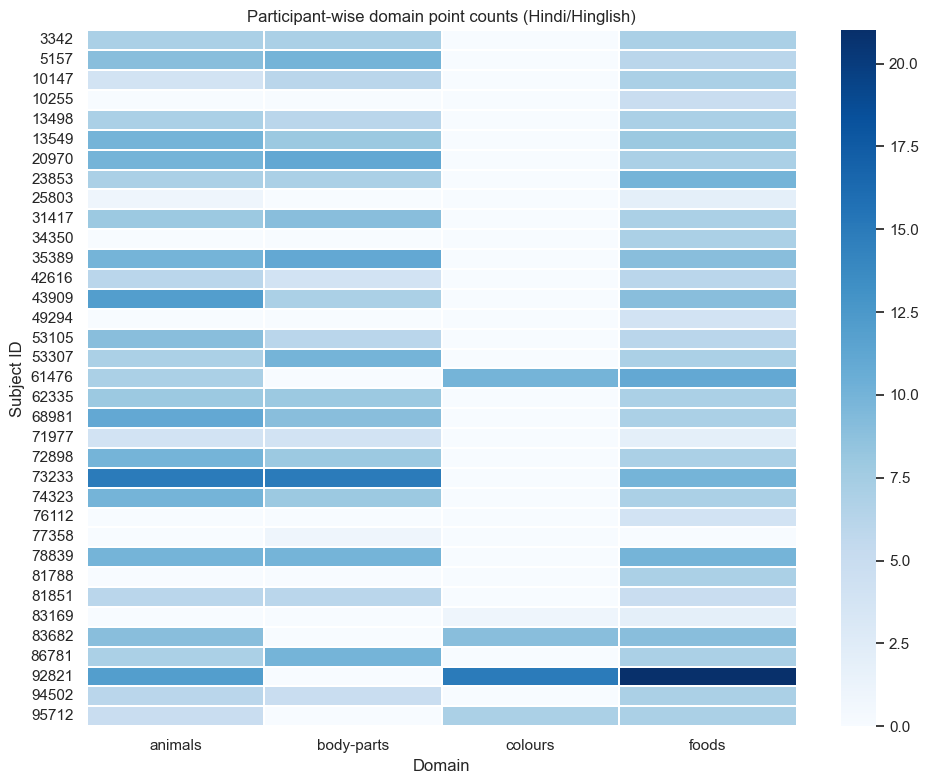

In [6]:
participant_domain_counts = (
    hh_spatial.groupby(["subject_id", "domain"])
    .size()
    .rename("n_points")
    .reset_index()
)

display(participant_domain_counts.head(10))

heatmap_df = participant_domain_counts.pivot(index="subject_id", columns="domain", values="n_points").fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_df, cmap="Blues", linewidths=0.3)
plt.title("Participant-wise domain point counts (Hindi/Hinglish)")
plt.xlabel("Domain")
plt.ylabel("Subject ID")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/hh_participant_domain_counts_heatmap.png", dpi=150)
plt.show()

C:\Users\ommeh\AppData\Local\Temp\ipykernel_11124\3243285476.py:24: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ommeh\AppData\Local\Temp\ipykernel_11124\3243285476.py:24: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
C:\Users\ommeh\AppData\Local\Temp\ipykernel_11124\3243285476.py:24: UserWarning: Glyph 2369 (\N{DEVANAGARI VOWEL SIGN U}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ommeh\AppData\Local\Temp\ipykernel_11124\3243285476.py:24: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ommeh\AppData\Local\Temp\ipykernel_11124\3243285476.py:24: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ommeh\AppData\Local\Temp\ipykernel_11124\3243285476.py:24: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) Arial.
  plt.tight

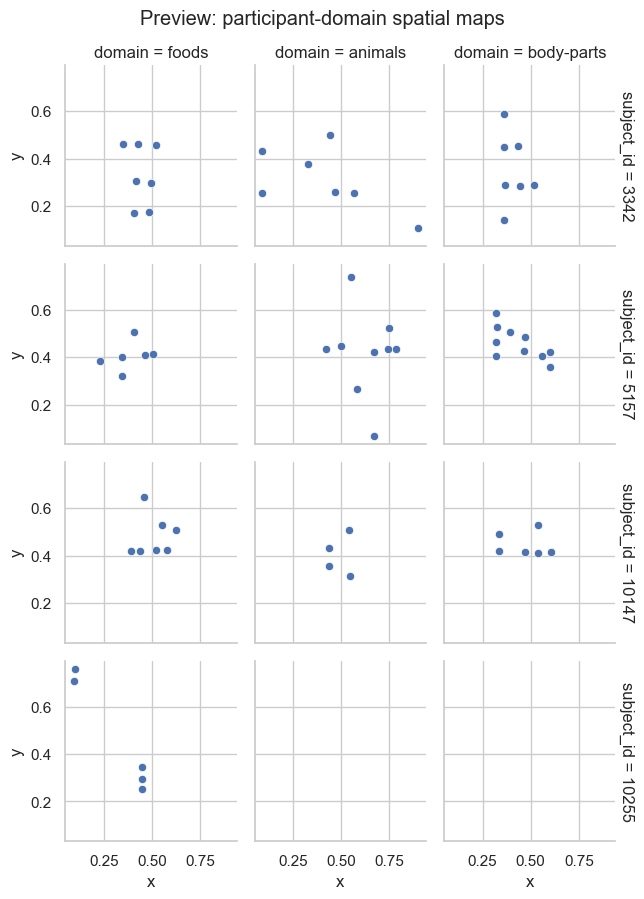

Saved participant-domain spatial maps for all available groups.


In [7]:
group_keys = (
    hh_spatial[["subject_id", "domain"]]
    .drop_duplicates()
    .sort_values(["subject_id", "domain"])
    .itertuples(index=False, name=None)
)

for subj, dom in group_keys:
    gdf = hh_spatial[(hh_spatial["subject_id"] == subj) & (hh_spatial["domain"] == dom)].copy()
    if gdf.empty:
        continue

    plt.figure(figsize=(6.5, 5.5))
    sns.scatterplot(data=gdf, x="x", y="y", s=55)

    for _, row in gdf.iterrows():
        plt.text(row["x"] + 0.01, row["y"] + 0.01, str(row["word"]), fontsize=8)

    plt.title(f"SpAM map | subject={subj}, domain={dom}")
    plt.xlabel("x (normalized)")
    plt.ylabel("y (normalized)")
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/map_subject_{subj}_domain_{dom}.png", dpi=150)
    plt.close()

SUBJECTS_TO_PREVIEW = sorted(hh_spatial["subject_id"].unique())[:4]
preview_df = hh_spatial[hh_spatial["subject_id"].isin(SUBJECTS_TO_PREVIEW)].copy()

preview = sns.FacetGrid(preview_df, row="subject_id", col="domain", margin_titles=True, height=2.2, aspect=1.0)
preview.map_dataframe(sns.scatterplot, x="x", y="y", s=35)
preview.set_axis_labels("x", "y")
preview.fig.suptitle("Preview: participant-domain spatial maps", y=1.02)
plt.show()

print("Saved participant-domain spatial maps for all available groups.")

In [8]:
pair_rows = []

for (subj, dom), grp in hh_spatial.groupby(["subject_id", "domain"]):
    grp = grp.reset_index(drop=True)
    if len(grp) < 2:
        continue

    coords = grp[["x", "y"]].to_numpy()
    words = grp["word"].astype(str).tolist()

    for i in range(len(grp)):
        for j in range(i + 1, len(grp)):
            d = float(np.linalg.norm(coords[i] - coords[j]))
            pair_rows.append({
                "subject_id": subj,
                "domain": dom,
                "word_1": words[i],
                "word_2": words[j],
                "distance": d
            })

pairwise_df = pd.DataFrame(pair_rows)
print("Pairwise rows:", len(pairwise_df))
display(pairwise_df.head(5))

Pairwise rows: 2781


,subject_id,domain,word_1,word_2,distance
0,3342,animals,कुत्ता,मछली,0.375356
1,3342,animals,कुत्ता,कछुआ,0.477609
2,3342,animals,कुत्ता,शेर,0.267078
3,3342,animals,कुत्ता,साँप,0.425686
4,3342,animals,कुत्ता,डायनासोर,0.823916


,subject_id,domain,mean_distance,total_words,cluster_count,mean_cluster_size
0,3342,animals,0.392383,7,1,7.0
1,3342,body-parts,0.205174,7,1,7.0
2,3342,foods,0.186265,7,1,7.0
3,5157,animals,0.279467,9,2,4.5
4,5157,body-parts,0.172535,10,1,10.0
5,5157,foods,0.151503,6,1,6.0
6,10147,animals,0.143138,4,1,4.0
7,10147,body-parts,0.161024,6,1,6.0
8,10147,foods,0.155968,7,1,7.0
9,10255,foods,0.360270,5,1,5.0


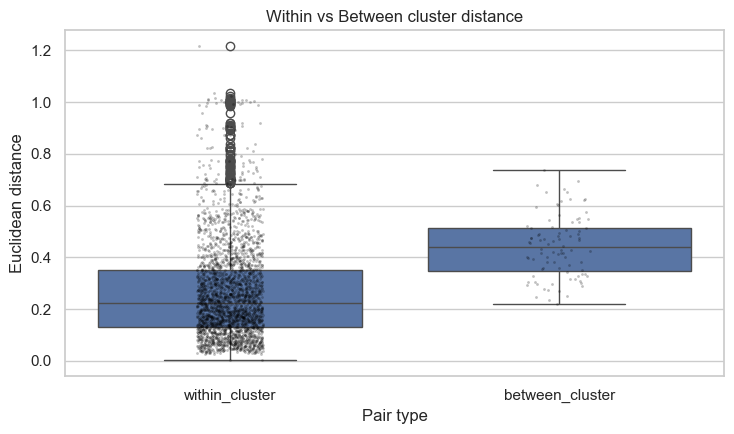

In [9]:
if pairwise_df.empty:
    print("No pairwise distances available (all groups have <2 words).")
else:
    # 4) Semantic neighbourhood: mean distance per word within (subject, domain)
    word_distance_rows = []
    for (subj, dom), grp in pairwise_df.groupby(["subject_id", "domain"]):
        words = sorted(set(grp["word_1"]).union(set(grp["word_2"])))
        for w in words:
            local = grp[(grp["word_1"] == w) | (grp["word_2"] == w)]
            word_distance_rows.append({
                "subject_id": subj,
                "domain": dom,
                "word": w,
                "mean_distance_to_others": float(local["distance"].mean())
            })

    word_distance_df = pd.DataFrame(word_distance_rows)

    # 5) Clusters using threshold = median(pairwise distances) within each (subject, domain)
    cluster_rows = []
    cluster_metrics_rows = []
    wb_rows = []

    for (subj, dom), grp in pairwise_df.groupby(["subject_id", "domain"]):
        threshold = float(grp["distance"].median())
        words = sorted(set(grp["word_1"]).union(set(grp["word_2"])))
        adjacency = {w: set() for w in words}

        below = grp[grp["distance"] <= threshold]
        for _, r in below.iterrows():
            a, b = r["word_1"], r["word_2"]
            adjacency[a].add(b)
            adjacency[b].add(a)

        cluster_id = 0
        visited = set()
        word_to_cluster = {}

        for w in words:
            if w in visited:
                continue
            cluster_id += 1
            stack = [w]
            members = []
            while stack:
                cur = stack.pop()
                if cur in visited:
                    continue
                visited.add(cur)
                members.append(cur)
                stack.extend(adjacency[cur] - visited)

            for m in members:
                word_to_cluster[m] = cluster_id

        for w in words:
            cluster_rows.append({
                "subject_id": subj,
                "domain": dom,
                "word": w,
                "cluster_id": word_to_cluster[w],
                "threshold_median_distance": threshold
            })

        cluster_sizes = pd.Series(list(word_to_cluster.values())).value_counts().sort_index()
        cluster_metrics_rows.append({
            "subject_id": subj,
            "domain": dom,
            "total_words": len(words),
            "cluster_count": int(cluster_sizes.shape[0]),
            "mean_cluster_size": float(cluster_sizes.mean())
        })

        # 6) Within vs Between cluster distances
        for _, r in grp.iterrows():
            c1 = word_to_cluster[r["word_1"]]
            c2 = word_to_cluster[r["word_2"]]
            wb_rows.append({
                "subject_id": subj,
                "domain": dom,
                "pair_type": "within_cluster" if c1 == c2 else "between_cluster",
                "distance": float(r["distance"])
            })

    clusters_df = pd.DataFrame(cluster_rows)
    cluster_metrics_df = pd.DataFrame(cluster_metrics_rows)
    within_between_df = pd.DataFrame(wb_rows)

    participant_summary = (
        pairwise_df.groupby(["subject_id", "domain"]) ["distance"]
        .mean()
        .rename("mean_distance")
        .reset_index()
        .merge(cluster_metrics_df, on=["subject_id", "domain"], how="left")
    )

    display(participant_summary.head(10))

    plt.figure(figsize=(7.5, 4.5))
    sns.boxplot(data=within_between_df, x="pair_type", y="distance")
    sns.stripplot(data=within_between_df, x="pair_type", y="distance", color="black", alpha=0.25, size=2)
    plt.title("Within vs Between cluster distance")
    plt.xlabel("Pair type")
    plt.ylabel("Euclidean distance")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/within_vs_between_cluster_distance.png", dpi=150)
    plt.show()

## 7) Distance Distribution per (Subject, Domain) + English Participation Counts

Saved distance histograms for preview groups.


,group_for_compare,n_rows,n_subjects,n_sessions
0,English,341,16,16
1,Hindi/Hinglish,699,35,35


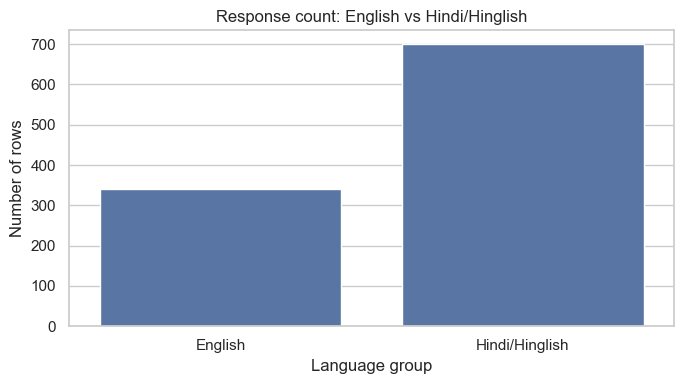

In [10]:
if not pairwise_df.empty:
    preview_groups = (
        pairwise_df[["subject_id", "domain"]]
        .drop_duplicates()
        .sort_values(["subject_id", "domain"])
        .head(6)
    )

    for _, g in preview_groups.iterrows():
        subj, dom = g["subject_id"], g["domain"]
        d = pairwise_df[(pairwise_df["subject_id"] == subj) & (pairwise_df["domain"] == dom)]

        plt.figure(figsize=(6, 4))
        sns.histplot(d["distance"], bins=12)
        plt.title(f"Distance distribution | subject={subj}, domain={dom}")
        plt.xlabel("Pairwise distance")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/hist_subject_{subj}_domain_{dom}.png", dpi=150)
        plt.close()

print("Saved distance histograms for preview groups.")

lang_counts = (
    spam_df.assign(group_for_compare=spam_df["language_group"].where(spam_df["language_group"] == "English", "Hindi/Hinglish"))
    .groupby("group_for_compare")
    .agg(
        n_rows=("word", "count"),
        n_subjects=("subject_id", "nunique"),
        n_sessions=("session_id", "nunique")
    )
    .reset_index()
)

display(lang_counts)

plt.figure(figsize=(7, 4))
sns.barplot(data=lang_counts, x="group_for_compare", y="n_rows")
plt.title("Response count: English vs Hindi/Hinglish")
plt.xlabel("Language group")
plt.ylabel("Number of rows")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/english_vs_hh_row_counts.png", dpi=150)
plt.show()

## 8) Aggregate Across Participants + SpAM-VFT Link

In [11]:
if "participant_summary" in globals() and not participant_summary.empty:
    agg_domain = (
        participant_summary.groupby("domain")
        .agg(
            mean_distance=("mean_distance", "mean"),
            mean_cluster_size=("mean_cluster_size", "mean"),
            mean_cluster_count=("cluster_count", "mean")
        )
        .reset_index()
    )
else:
    agg_domain = pd.DataFrame(columns=["domain", "mean_distance", "mean_cluster_size", "mean_cluster_count"])

display(agg_domain)

# SpAM-VFT link proxy using rt_ms from merged file
if "rt_ms" in hh_spatial.columns and "word_distance_df" in globals() and not word_distance_df.empty:
    rt_word = (
        hh_spatial.groupby(["subject_id", "domain", "word"]) ["rt_ms"]
        .mean()
        .rename("mean_irt")
        .reset_index()
    )

    spam_vft_link = word_distance_df.merge(rt_word, on=["subject_id", "domain", "word"], how="inner")
    display(spam_vft_link.head(10))
else:
    spam_vft_link = pd.DataFrame(columns=["subject_id", "domain", "word", "mean_distance_to_others", "mean_irt"])
    print("SpAM-VFT link skipped: missing rt_ms or word-level distance table.")

,domain,mean_distance,mean_cluster_size,mean_cluster_count
0,animals,0.291792,7.611111,1.185185
1,body-parts,0.241809,7.652174,1.086957
2,colours,0.293512,9.500000,1.000000
3,foods,0.316987,6.470588,1.205882


,subject_id,domain,word,mean_distance_to_others,mean_irt
0,3342,animals,कछुआ,0.332730,8485.6
1,3342,animals,कुत्ता,0.424159,8739.3
2,3342,animals,डायनासोर,0.626750,10374.9
3,3342,animals,बंदर,0.428116,8158.9
4,3342,animals,मछली,0.296255,8200.9
5,3342,animals,शेर,0.293155,7849.3
6,3342,animals,साँप,0.345519,7855.8
7,3342,body-parts,आंख,0.197387,6840.0
8,3342,body-parts,उंगली,0.281794,7831.3
9,3342,body-parts,कान,0.167329,6866.6


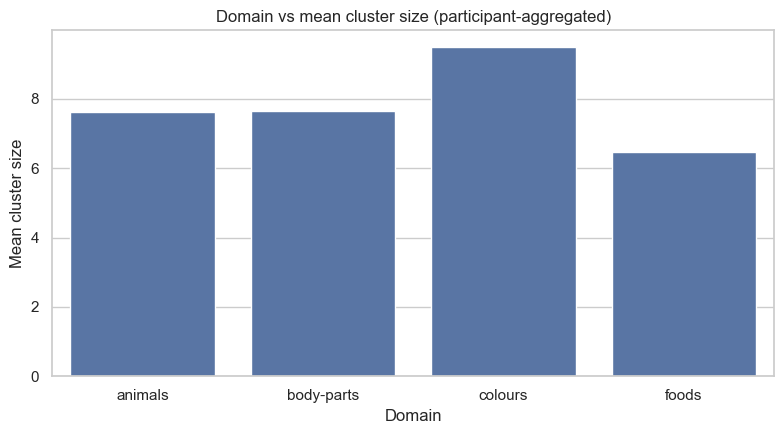

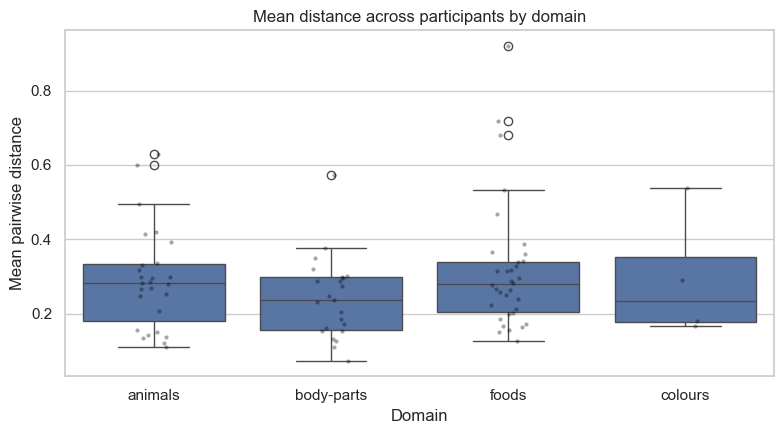

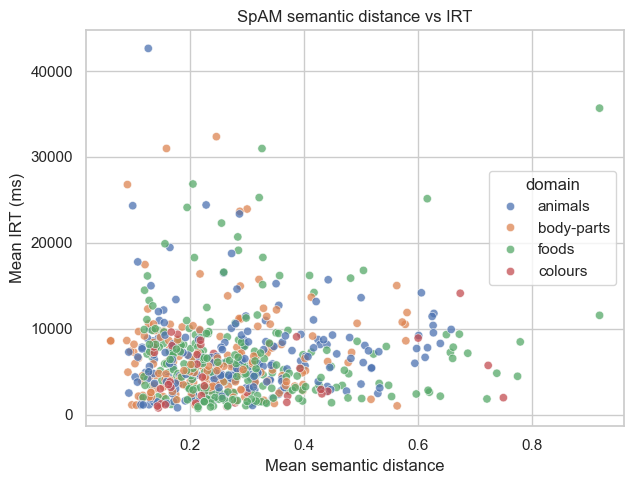

In [12]:
if not agg_domain.empty:
    plt.figure(figsize=(8, 4.5))
    sns.barplot(data=agg_domain, x="domain", y="mean_cluster_size")
    plt.title("Domain vs mean cluster size (participant-aggregated)")
    plt.xlabel("Domain")
    plt.ylabel("Mean cluster size")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/aggregate_domain_mean_cluster_size.png", dpi=150)
    plt.show()

if "participant_summary" in globals() and not participant_summary.empty:
    plt.figure(figsize=(8, 4.5))
    sns.boxplot(data=participant_summary, x="domain", y="mean_distance")
    sns.stripplot(data=participant_summary, x="domain", y="mean_distance", color="black", alpha=0.35, size=3)
    plt.title("Mean distance across participants by domain")
    plt.xlabel("Domain")
    plt.ylabel("Mean pairwise distance")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/aggregate_mean_distance_boxplot.png", dpi=150)
    plt.show()

if "spam_vft_link" in globals() and not spam_vft_link.empty:
    plt.figure(figsize=(6.5, 5))
    sns.scatterplot(data=spam_vft_link, x="mean_distance_to_others", y="mean_irt", hue="domain", alpha=0.75)
    plt.title("SpAM semantic distance vs IRT")
    plt.xlabel("Mean semantic distance")
    plt.ylabel("Mean IRT (ms)")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/spam_distance_vs_irt_scatter.png", dpi=150)
    plt.show()

## 9) Save Processed Outputs

In [13]:
hh_spatial.to_csv(f"{OUT_DIR}/hh_spatial_clean.csv", index=False)
hh_summary.to_csv(f"{OUT_DIR}/hh_domain_summary.csv", index=False)
lang_counts.to_csv(f"{OUT_DIR}/english_vs_hh_counts.csv", index=False)
participant_domain_counts.to_csv(f"{OUT_DIR}/hh_participant_domain_counts.csv", index=False)

if "pairwise_df" in globals() and not pairwise_df.empty:
    pairwise_df.to_csv(f"{OUT_DIR}/pairwise_distances_subject_domain.csv", index=False)
if "word_distance_df" in globals() and not word_distance_df.empty:
    word_distance_df.to_csv(f"{OUT_DIR}/word_semantic_neighbourhood.csv", index=False)
if "clusters_df" in globals() and not clusters_df.empty:
    clusters_df.to_csv(f"{OUT_DIR}/cluster_membership_subject_domain.csv", index=False)
if "cluster_metrics_df" in globals() and not cluster_metrics_df.empty:
    cluster_metrics_df.to_csv(f"{OUT_DIR}/cluster_metrics_subject_domain.csv", index=False)
if "within_between_df" in globals() and not within_between_df.empty:
    within_between_df.to_csv(f"{OUT_DIR}/within_between_cluster_distances.csv", index=False)
if "participant_summary" in globals() and not participant_summary.empty:
    participant_summary.to_csv(f"{OUT_DIR}/participant_domain_summary.csv", index=False)
if "agg_domain" in globals() and not agg_domain.empty:
    agg_domain.to_csv(f"{OUT_DIR}/aggregate_domain_summary.csv", index=False)
if "spam_vft_link" in globals() and not spam_vft_link.empty:
    spam_vft_link.to_csv(f"{OUT_DIR}/spam_vft_link_word_level.csv", index=False)

stale_files = [
    "hh_participant_domain_distance.csv",
    "hh_participant_domain_distance_boxplot.png",
    "hh_segment_compare.csv",
    "hh_segment_compare_with_english_reference.png",
    "hh_pairwise_distances.csv"
]
for stale in stale_files:
    stale_path = os.path.join(OUT_DIR, stale)
    if os.path.exists(stale_path):
        os.remove(stale_path)

print("Saved outputs to:", OUT_DIR)
print("Files:")
for fn in sorted(os.listdir(OUT_DIR)):
    print(" -", fn)

Saved outputs to: outputs_spam_hinglish
Files:
 - aggregate_domain_mean_cluster_size.png
 - aggregate_domain_summary.csv
 - aggregate_mean_distance_boxplot.png
 - cluster_membership_subject_domain.csv
 - cluster_metrics_subject_domain.csv
 - english_vs_hh_counts.csv
 - english_vs_hh_row_counts.png
 - hh_domain_summary.csv
 - hh_participant_domain_counts.csv
 - hh_participant_domain_counts_heatmap.png
 - hh_participant_domain_scatter_sample.png
 - hh_spatial_clean.csv
 - hist_subject_3342_domain_animals.png
 - hist_subject_3342_domain_body-parts.png
 - hist_subject_3342_domain_foods.png
 - hist_subject_5157_domain_animals.png
 - hist_subject_5157_domain_body-parts.png
 - hist_subject_5157_domain_foods.png
 - map_subject_10147_domain_animals.png
 - map_subject_10147_domain_body-parts.png
 - map_subject_10147_domain_foods.png
 - map_subject_10255_domain_foods.png
 - map_subject_13498_domain_animals.png
 - map_subject_13498_domain_body-parts.png
 - map_subject_13498_domain_foods.png
 - map